# Méthodes de gradient proximal — ISTA & FISTA
### Résoudre un problème convexe quand la fonction n'est pas dérivable

**Projet d'optimisation convexe — Sujet B**

> Ce notebook est le fil conducteur du projet. Il part du *pourquoi* (quel problème, pourquoi les méthodes du cours ne suffisent pas) et construit pas à pas le chemin jusqu'aux algorithmes **ISTA** et **FISTA**. Chaque membre du groupe prolonge ensuite une section (théorie, preuves, état de l'art, application audio).

---
*Sommaire*
1. Le cadre : de l'optimisation convexe du cours à notre problème
2. Un problème concret : retrouver un signal parcimonieux
3. Pourquoi les méthodes du cours échouent ici
4. L'idée clé : l'opérateur proximal
5. ISTA : l'algorithme de base
6. FISTA : la même idée, accélérée
7. La course de convergence
8. Ce que la suite du projet va construire


## 0. Mise en place

On importe les bibliothèques et on fixe un style graphique homogène pour toutes les figures du projet (palette sobre, typographie lisible). On définit aussi une graine aléatoire pour que les résultats soient **reproductibles**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cycler

# --- Style graphique commun au projet -------------------------------------
PALETTE = ["#2E5EAA", "#E07A3F", "#3C9D6E", "#9B5DE5", "#444444"]
plt.rcParams.update({
    "figure.figsize":      (8, 5),
    "figure.dpi":          120,
    "axes.prop_cycle":     cycler(color=PALETTE),
    "axes.spines.top":     False,
    "axes.spines.right":   False,
    "axes.grid":           True,
    "grid.alpha":          0.25,
    "grid.linestyle":      "--",
    "axes.titlesize":      14,
    "axes.titleweight":    "bold",
    "axes.labelsize":      11,
    "font.family":         "DejaVu Sans",
    "legend.frameon":      False,
})

RNG = np.random.default_rng(0)   # reproductibilite
print("Environnement pret.")

Environnement pret.


## 1. Du cours à notre problème

Le cours nous a appris qu'un **problème d'optimisation convexe** s'écrit

$$\min_{x \in A} \; f(x)$$

où la fonction objectif $f$ est **convexe** et l'ensemble admissible $A$ est **convexe**. Sa propriété fondamentale — la *propriété-or* — est que :

> pour une fonction convexe, **tout minimum local est un minimum global**.

Autrement dit : pas de piège, pas de "creux" sous-optimal, un seul sommet à atteindre.

Le cours a ensuite donné deux familles de méthodes de résolution :

| Cas | Méthode vue en cours | Hypothèse nécessaire |
|---|---|---|
| objectif **lisse** | descente de gradient, Newton | $f$ **dérivable** partout |
| objectif **linéaire** | simplex | $f$ et contraintes **linéaires** |

**La question de ce projet :** que se passe-t-il quand $f$ est convexe mais **ni lisse ni linéaire** ? C'est un cas extrêmement courant, et aucune des deux méthodes ci-dessus ne s'applique directement. C'est là qu'interviennent les **méthodes de gradient proximal**.

## 2. Un problème concret : retrouver un signal parcimonieux

Plaçons-nous dans une situation typique. On observe un vecteur de mesures $y \in \mathbb{R}^n$, relié à un vecteur inconnu $x \in \mathbb{R}^p$ par une matrice connue $A \in \mathbb{R}^{n \times p}$ :

$$y = A\,x + \text{bruit}.$$

Le point crucial : **il y a plus d'inconnues que de mesures** ($p > n$). Le système est *sous-déterminé* — il admet une infinité de solutions $x$ compatibles avec $y$. Sans information supplémentaire, le problème est mal posé.

L'information qu'on ajoute : on sait que le vrai signal est **parcimonieux** (*sparse*), c'est-à-dire qu'il n'a que **quelques coefficients non nuls**. C'est une hypothèse réaliste — beaucoup de signaux naturels (audio, images) ont une représentation creuse dans une bonne base.

Fabriquons un tel problème pour le manipuler.

In [2]:
# Dimensions : plus d'inconnues (p) que de mesures (n) -> systeme sous-determine
n, p, k = 100, 300, 10        # n mesures, p variables, k coefficients non nuls

# Matrice de mesure A (gaussienne, normalisee)
A = RNG.standard_normal((n, p)) / np.sqrt(n)

# Vrai signal parcimonieux : seulement k coefficients non nuls
x_true = np.zeros(p)
support = RNG.choice(p, k, replace=False)      # positions des coeffs non nuls
x_true[support] = RNG.standard_normal(k)       # valeurs

# Observation bruitee
y = A @ x_true + 0.01 * RNG.standard_normal(n)

print(f"x a {p} composantes, dont seulement {k} non nulles.")
print(f"On observe seulement {n} mesures.")
print(f"-> {p} inconnues pour {n} equations : infinite de solutions possibles.")

x a 300 composantes, dont seulement 10 non nulles.
On observe seulement 100 mesures.
-> 300 inconnues pour 100 equations : infinite de solutions possibles.


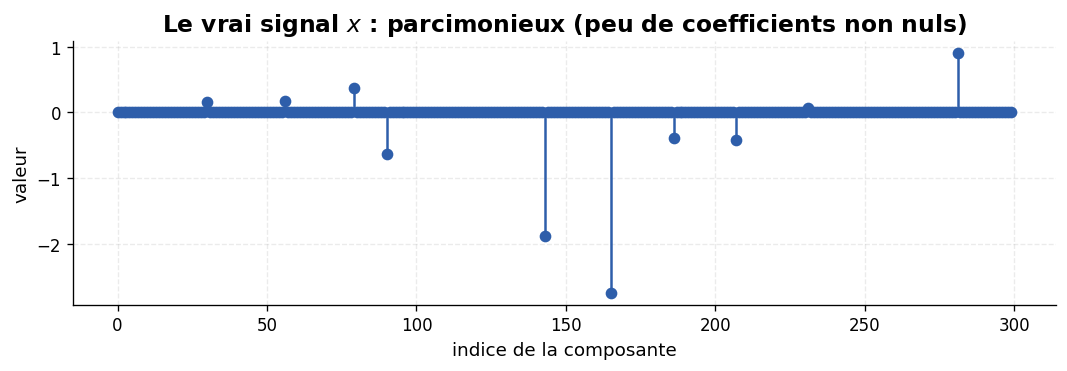

In [3]:
# Visualisons le vrai signal : un vecteur creux
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.stem(x_true, linefmt="-", markerfmt="o", basefmt=" ")
ax.set_title("Le vrai signal $x$ : parcimonieux (peu de coefficients non nuls)")
ax.set_xlabel("indice de la composante")
ax.set_ylabel("valeur")
plt.tight_layout()
plt.show()

Pour retrouver $x$, on minimise un objectif en **deux morceaux** :

$$\min_{x \in \mathbb{R}^p} \; F(x) = \underbrace{\tfrac{1}{2}\,\lVert A x - y \rVert_2^2}_{f(x)\ :\ \text{fidélité aux données}} \;+\; \lambda \underbrace{\lVert x \rVert_1}_{g(x)\ :\ \text{parcimonie}}$$

- Le premier terme $f(x)$ pousse $x$ à **expliquer les mesures** $y$. Il est quadratique, donc lisse et convexe.
- Le second terme $\lambda\lVert x\rVert_1 = \lambda\sum_i |x_i|$ **pénalise les coefficients non nuls** et force la solution à être creuse. Il est convexe, mais **non dérivable**.
- $\lambda > 0$ règle le compromis entre les deux.

Ce problème porte un nom : c'est le **LASSO**. Vérifions d'abord qu'il est bien **convexe**, pour rester dans le cadre du cours.

### 2.1 Le problème est-il convexe ?

On le justifie avec les règles du cours :

1. $f(x) = \tfrac12\lVert Ax - y\rVert_2^2$ est une fonction **quadratique** dont la matrice hessienne est $A^\top A$, qui est **semi-définie positive** (car $u^\top A^\top A\,u = \lVert Au\rVert^2 \ge 0$). Donc $f$ est convexe.
2. $g(x) = \lambda\lVert x\rVert_1$ est une **norme** (multipliée par $\lambda>0$), or toute norme est convexe.
3. **Une somme de fonctions convexes est convexe** (vu en TD). Donc $F = f + g$ est convexe.
4. L'ensemble admissible est $\mathbb{R}^p$ tout entier, qui est trivialement convexe.

$F$ est donc une fonction convexe sur un ensemble convexe : la **propriété-or** s'applique, il existe un minimum global et c'est lui qu'on cherche. ✓

## 3. Pourquoi les méthodes du cours échouent ici

Le terme $\lVert x\rVert_1$ contient des valeurs absolues $|x_i|$. Or la fonction $t \mapsto |t|$ présente un **coin en 0** : sa dérivée vaut $-1$ à gauche, $+1$ à droite, et **n'existe pas en 0**.

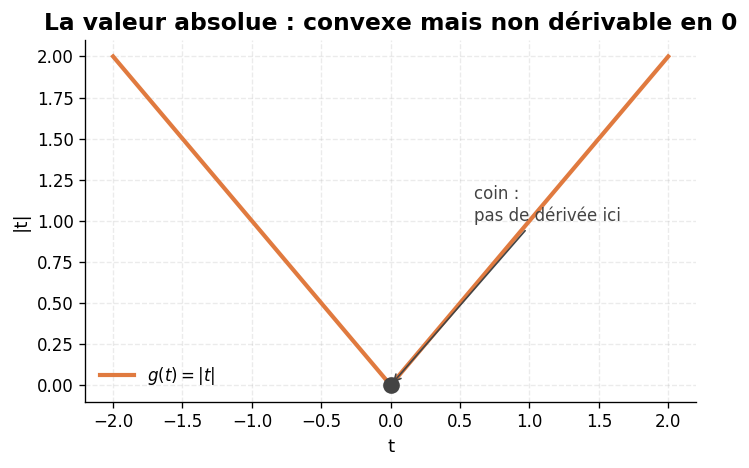

In [4]:
# Le point de blocage : la valeur absolue n'est pas derivable en 0
t = np.linspace(-2, 2, 400)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(t, np.abs(t), color=PALETTE[1], lw=2.5, label="$g(t) = |t|$")
ax.plot(0, 0, "o", color=PALETTE[4], ms=9, zorder=5)
ax.annotate("coin :\npas de dérivée ici", xy=(0, 0), xytext=(0.6, 1.0),
            arrowprops=dict(arrowstyle="->", color=PALETTE[4]),
            fontsize=10, color=PALETTE[4])
ax.set_title("La valeur absolue : convexe mais non dérivable en 0")
ax.set_xlabel("t"); ax.set_ylabel("|t|"); ax.legend()
plt.tight_layout()
plt.show()

**Conséquence directe :**

- La **descente de gradient** a besoin du gradient $\nabla F$. Mais $\nabla F$ n'existe pas là où des composantes de $x$ valent 0 — et c'est précisément là que se trouve la solution (creuse !). Inutilisable.
- La **méthode de Newton** exige en plus la dérivée seconde. Encore pire.
- Le **simplex** ne traite que les objectifs **linéaires** ; le nôtre est quadratique. Hors sujet.

Il nous faut donc un outil capable de gérer ce "coin". Cet outil, c'est l'**opérateur proximal**.

## 4. L'idée clé : l'opérateur proximal

L'astuce des méthodes proximales : **séparer** le traitement des deux morceaux $f$ (lisse) et $g$ (non lisse).

- Sur $f$, lisse, on sait faire : un **pas de gradient** ordinaire.
- Sur $g$, non lisse, on remplace le pas de gradient par un **pas proximal**, défini par :

$$\operatorname{prox}_{t g}(z) = \arg\min_{u}\; \Big(\, g(u) + \frac{1}{2t}\lVert u - z\rVert_2^2 \,\Big).$$

Intuition : « reste proche de $z$ (terme quadratique), tout en réduisant $g$ ». L'opérateur proximal est une façon de "faire un pas" sur une fonction même non dérivable.

**Le miracle pour la norme $L_1$ :** ce sous-problème se résout *à la main*, coordonnée par coordonnée, et donne une formule explicite — le **seuillage doux** (*soft-thresholding*) :

$$\operatorname{prox}_{t\lambda\lVert\cdot\rVert_1}(z)_i = \operatorname{sign}(z_i)\,\max\big(|z_i| - t\lambda,\; 0\big).$$

En clair : tout coefficient plus petit que le seuil $t\lambda$ est **mis à zéro** (→ parcimonie !), les autres sont **rétractés** vers zéro de $t\lambda$.

> *La dérivation rigoureuse de cette formule est l'objet de la section théorique du rapport (Membre 2). Ici on l'admet et on la visualise.*

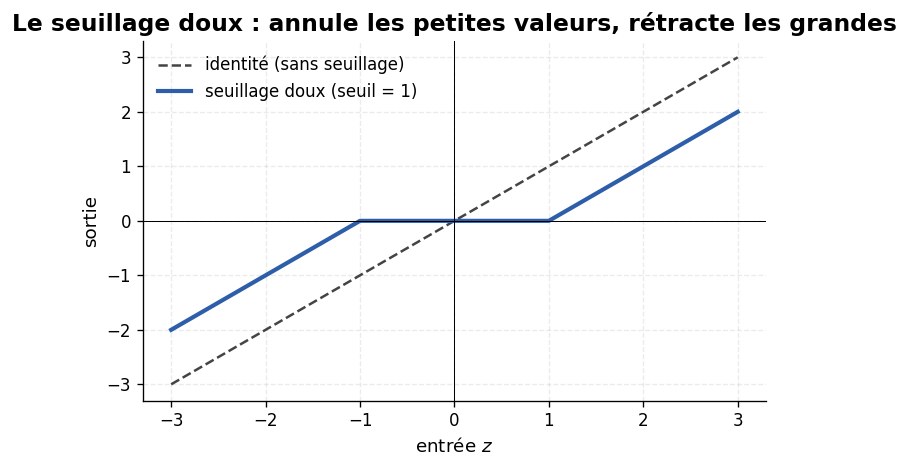

In [5]:
def soft_threshold(z, seuil):
    '''Operateur proximal de la norme L1 : seuillage doux, composante par composante.'''
    return np.sign(z) * np.maximum(np.abs(z) - seuil, 0.0)

# Visualisation : effet du seuillage doux
z = np.linspace(-3, 3, 400)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(z, z, "--", color=PALETTE[4], lw=1.5, label="identité (sans seuillage)")
ax.plot(z, soft_threshold(z, 1.0), color=PALETTE[0], lw=2.5, label="seuillage doux (seuil = 1)")
ax.axhline(0, color="k", lw=0.6); ax.axvline(0, color="k", lw=0.6)
ax.set_title("Le seuillage doux : annule les petites valeurs, rétracte les grandes")
ax.set_xlabel("entrée $z$"); ax.set_ylabel("sortie"); ax.legend()
plt.tight_layout()
plt.show()

On voit nettement la **zone morte** $[-1, 1]$ où tout est écrasé à zéro : c'est ce mécanisme qui crée la parcimonie. C'est l'ingrédient unique qui rend ISTA et FISTA possibles.

## 5. ISTA : l'algorithme de base

**ISTA** (*Iterative Shrinkage-Thresholding Algorithm*) répète simplement, à chaque itération :

1. un **pas de gradient** sur la partie lisse : $\;z = x_k - t\,\nabla f(x_k)\;$ avec $\;\nabla f(x) = A^\top(Ax - y)$,
2. un **pas proximal** sur la partie non lisse : $\;x_{k+1} = \operatorname{prox}_{t\lambda\lVert\cdot\rVert_1}(z)$.

En une ligne :

$$\boxed{\,x_{k+1} = \operatorname{soft\_threshold}\big(x_k - t\,A^\top(Ax_k - y),\; t\lambda\big)\,}$$

Le pas $t$ doit vérifier $t \le 1/L$, où $L = \lVert A^\top A\rVert_2$ est la **constante de Lipschitz** du gradient de $f$ (la plus grande valeur propre de $A^\top A$). C'est la condition qui garantit la convergence.

In [6]:
def objective(A, y, lam, x):
    '''F(x) = 1/2 ||Ax - y||^2 + lambda ||x||_1.'''
    r = A @ x - y
    return 0.5 * r @ r + lam * np.sum(np.abs(x))

def ista(A, y, lam, t, n_iter, x0=None):
    '''ISTA. Renvoie (x, history) ou history = valeurs de F a chaque iteration.'''
    x = np.zeros(A.shape[1]) if x0 is None else x0.copy()
    history = []
    for _ in range(n_iter):
        grad = A.T @ (A @ x - y)                     # gradient de f
        x = soft_threshold(x - t * grad, t * lam)    # pas de gradient + prox
        history.append(objective(A, y, lam, x))
    return x, history

print("ISTA defini.")

ISTA defini.


In [7]:
# Constante de Lipschitz et pas
L = np.linalg.norm(A, 2) ** 2
t = 1.0 / L
lam = 0.05
print(f"L = {L:.3f}  ->  pas t = 1/L = {t:.4f}")

x_ista, hist_ista = ista(A, y, lam, t, n_iter=500)
print(f"Coefficients non nuls retrouves (seuil 1e-3) : {np.sum(np.abs(x_ista) > 1e-3)}  (vrai : {k})")

L = 7.022  ->  pas t = 1/L = 0.1424
Coefficients non nuls retrouves (seuil 1e-3) : 11  (vrai : 10)


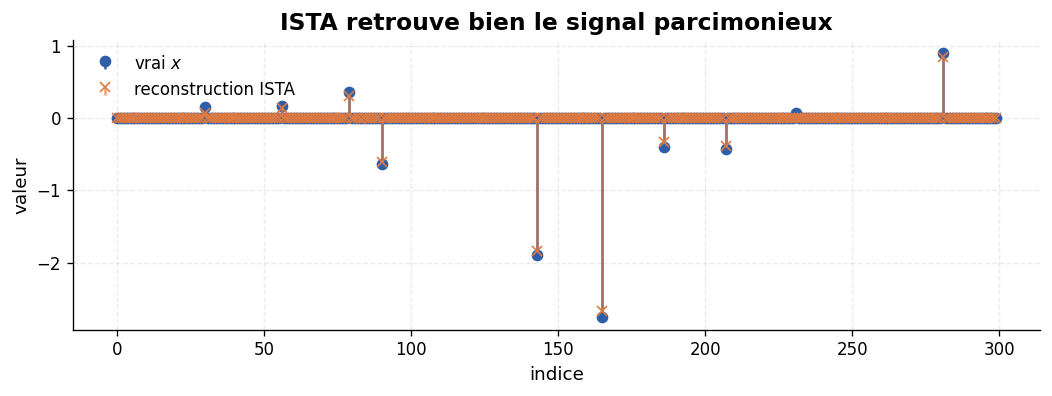

In [8]:
# Comparaison vrai signal vs reconstruction ISTA
fig, ax = plt.subplots(figsize=(9, 3.4))
ax.stem(x_true, linefmt="-", markerfmt="o", basefmt=" ", label="vrai $x$")
markerline, stemline, _ = ax.stem(x_ista, linefmt="-", markerfmt="x", basefmt=" ", label="reconstruction ISTA")
plt.setp(stemline, color=PALETTE[1], alpha=0.7)
plt.setp(markerline, color=PALETTE[1])
ax.set_title("ISTA retrouve bien le signal parcimonieux")
ax.set_xlabel("indice"); ax.set_ylabel("valeur"); ax.legend()
plt.tight_layout()
plt.show()

## 6. FISTA : la même idée, accélérée

ISTA fonctionne, mais converge lentement. **FISTA** (*Fast ISTA*, Beck & Teboulle 2009) ajoute un **momentum** (élan) inspiré de Nesterov : au lieu de partir du dernier point, on part d'un point **extrapolé** $y_k$ qui anticipe la trajectoire en combinant les deux derniers itérés.

Concrètement, une seule ligne de plus qu'ISTA :

$$
\begin{aligned}
x_{k} &= \operatorname{prox}_{t\lambda\lVert\cdot\rVert_1}\!\big(y_k - t\,\nabla f(y_k)\big),\\
t_{k+1} &= \tfrac{1}{2}\big(1 + \sqrt{1 + 4 t_k^2}\big),\\
y_{k+1} &= x_k + \tfrac{t_k - 1}{t_{k+1}}\,(x_k - x_{k-1}).
\end{aligned}
$$

Le terme $(x_k - x_{k-1})$ est la "vitesse" : on continue dans la direction du progrès récent. Coût supplémentaire par itération : quasi nul. Gain : on passe d'une convergence en $O(1/k)$ à $O(1/k^2)$.

In [9]:
def fista(A, y, lam, t, n_iter, x0=None):
    '''FISTA : ISTA + momentum de Nesterov. O(1/k^2).'''
    x = np.zeros(A.shape[1]) if x0 is None else x0.copy()
    x_prev = x.copy()
    yk = x.copy()
    tk = 1.0
    history = []
    for _ in range(n_iter):
        grad = A.T @ (A @ yk - y)
        x = soft_threshold(yk - t * grad, t * lam)
        tk_next = (1.0 + np.sqrt(1.0 + 4.0 * tk ** 2)) / 2.0
        yk = x + ((tk - 1.0) / tk_next) * (x - x_prev)   # extrapolation
        x_prev = x.copy()
        tk = tk_next
        history.append(objective(A, y, lam, x))
    return x, history

x_fista, hist_fista = fista(A, y, lam, t, n_iter=500)
print(f"F(ISTA)  = {hist_ista[-1]:.6f}")
print(f"F(FISTA) = {hist_fista[-1]:.6f}   (meme optimum : la convexite garantit l'unicite)")

F(ISTA)  = 0.377305
F(FISTA) = 0.377305   (meme optimum : la convexite garantit l'unicite)


## 7. La course de convergence

On compare maintenant la **vitesse** des deux algorithmes. On trace l'écart à l'optimum $F(x_k) - F^\star$ en fonction de l'itération $k$, en échelle log-log.

- $F^\star$ est estimé en laissant FISTA tourner très longtemps (5000 itérations).
- En abscisse : le numéro d'itération. En ordonnée : « combien on est encore loin de l'optimum ». **Plus ça descend vite, mieux c'est.**

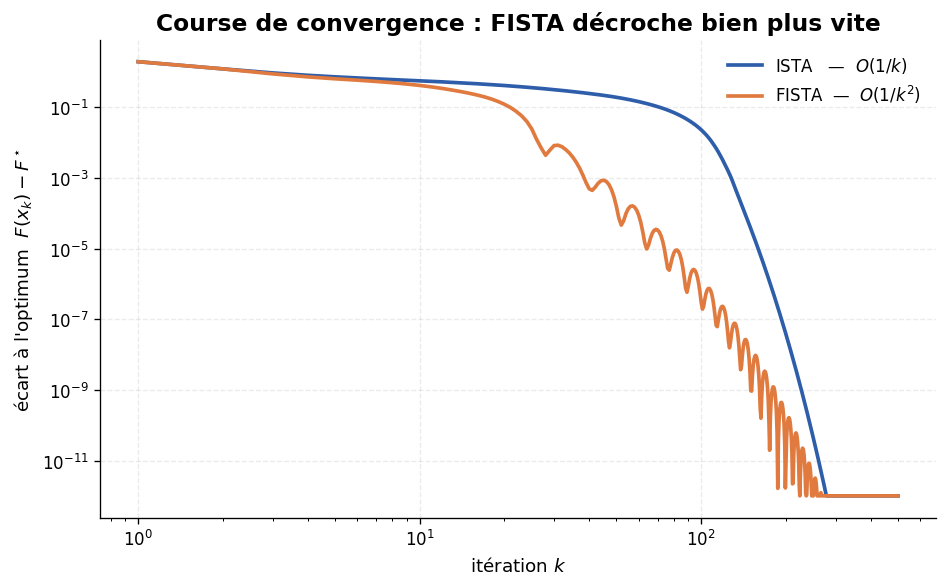

In [10]:
# Estimation de F* (optimum) en convergeant longuement
_, hist_ref = fista(A, y, lam, t, 5000)
F_star = hist_ref[-1]

gap_ista  = np.maximum(np.array(hist_ista)  - F_star, 1e-12)
gap_fista = np.maximum(np.array(hist_fista) - F_star, 1e-12)

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(range(1, 501), gap_ista,  lw=2.2, label="ISTA   —  $O(1/k)$")
ax.loglog(range(1, 501), gap_fista, lw=2.2, label="FISTA  —  $O(1/k^2)$")
ax.set_title("Course de convergence : FISTA décroche bien plus vite")
ax.set_xlabel("itération $k$")
ax.set_ylabel(r"écart à l'optimum  $F(x_k) - F^\star$")
ax.legend()
plt.tight_layout()
plt.show()

**Lecture de la figure :**

- FISTA atteint une précision donnée en **bien moins d'itérations** qu'ISTA — c'est l'effet du momentum.
- Les **oscillations** de FISTA viennent de l'extrapolation : la méthode n'est pas strictement monotone (elle "dépasse" parfois). C'est normal et connu ; cela motive des variantes avec *restart* (à discuter dans le rapport).
- Les deux courbes finissent par s'effondrer vers $F^\star$ : **même optimum**, conformément à la convexité.

C'est la figure centrale du projet : elle illustre visuellement le résultat théorique $O(1/k)$ vs $O(1/k^2)$ que les preuves établiront.

## 8. Ce que la suite du projet va construire

À partir de ce socle, chaque membre prolonge une direction (voir le document de répartition) :

- **Théorie proximale (Membre 2)** — sous-différentiel, conditions d'optimalité, **dérivation rigoureuse du seuillage doux**, propriétés de l'opérateur proximal.
- **Algorithmes & preuves (Membre 3)** — construction d'ISTA comme *majoration-minimisation*, **preuve de convergence $O(1/k)$** ; FISTA et l'**argument $O(1/k^2)$** de Beck & Teboulle.
- **État de l'art & expériences (Membre 4)** — comparaison avec *coordinate descent*, **ADMM**, *proximal Newton* ; étude de sensibilité à $\lambda$ et au pas $t$ ; puis l'**application à la séparation de sources audio** (bonus).
- **Cadre & intégration (Membre 1)** — formulation du problème, ancrage dans le cours, cohérence des notations, rédaction transversale.

> Le notebook restera le **fil narratif commun** : chacun branche sa contribution sur la trame ci-dessus, en réutilisant les fonctions `soft_threshold`, `ista`, `fista` et le style graphique défini en section 0.
